CT shape : (512, 512, 204)
GT shape : (512, 512, 204)
GT voxels: 12432
Loading Merlin...


Some weights of LongformerModel were not initialized from the model checkpoint at yikuan8/Clinical-Longformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading checkpoint for 'default' task from /home/chest_ct/code/.venv/lib/python3.12/site-packages/merlin/models/checkpoints/i3_resnet_clinical_longformer_best_clip_04-02-2024_23-21-36_epoch_99.pt
Merlin loaded on cuda
Merlin device: cuda:0

Input tensor:
torch.Size([1, 1, 128, 128, 102])
requires_grad: True

Image embedding: torch.Size([1, 512])
Text embedding: torch.Size([1, 512])

CAM:
(128, 128, 102)
Range: 0.0 1.0
Std: 0.16965213

CAM resolution comparison
CAM: (128, 128, 102)
GT: (128, 128, 102)

Threshold evaluation
--------------------
70% Dice = 0.0004
75% Dice = 0.0004
80% Dice = 0.0004
85% Dice = 0.0004
90% Dice = 0.0003
95% Dice = 0.0000

Best CAM threshold: 0.20448193
Best low-res Dice: 0.00044478454254147864

Pointing accuracy: False

Full CAM: (512, 512, 204)
Saved CAM NIfTI

Final Grad-CAM Evaluation
Dice      : 0.0004
IoU       : 0.0002
Precision : 0.0002
Recall    : 0.2405


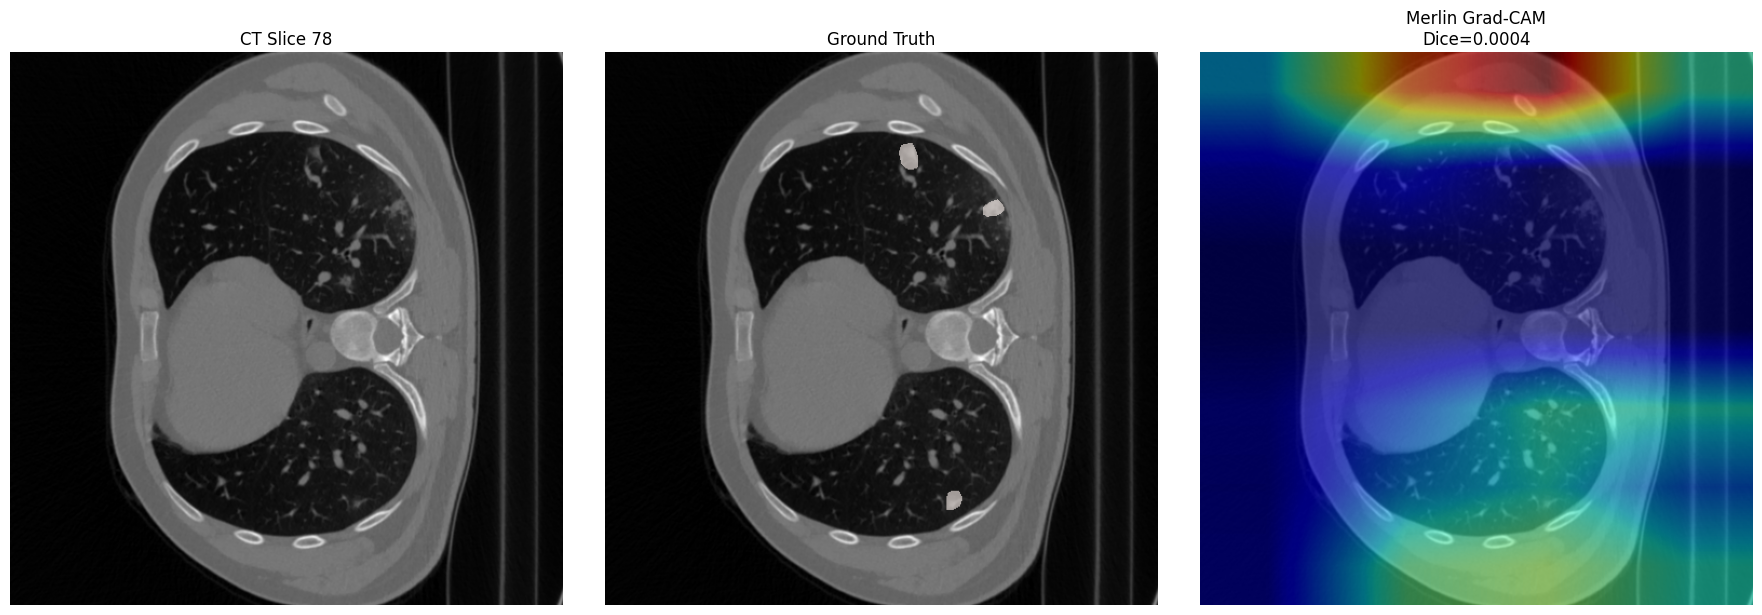

In [2]:
import os
import sys
import torch
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom


# ============================================================
# Merlin import
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/merlin"
)


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12991_a_1.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_12991_a_1.nii.gz"


assert os.path.exists(ct_path), "CT not found"
assert os.path.exists(gt_path), "GT not found"



# ============================================================
# Load CT + Ground Truth
# ============================================================

ct_nii = nib.load(ct_path)
gt_nii = nib.load(gt_path)


ct = ct_nii.get_fdata()
gt = gt_nii.get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt_mask = gt > 0



print("CT shape :", ct.shape)
print("GT shape :", gt_mask.shape)
print("GT voxels:", gt_mask.sum())



# ============================================================
# Load Merlin
# ============================================================

from explainability.inference.load_model import load_merlin
from explainability.inference.preprocess import preprocess_ct
from explainability.gradcam.gradcam3d import GradCAM3D



model, target_layer = load_merlin(
    image_embedding_only=True
)


device = next(model.parameters()).device


print(
    "Merlin device:",
    device
)



# ============================================================
# IMPORTANT FIX
# Enable contrastive projection head
# 2048 -> 512 embedding
# ============================================================

model.model.encode_image.i3_resnet.ImageEmbedding = False



# ============================================================
# Image forward for Grad-CAM
# ============================================================

def image_forward(x):

    output = model.model.encode_image(x)

    # ImageEmbedding=False returns:
    # (image_embedding, ehr_embedding)

    image_embedding, ehr_embedding = output

    return image_embedding



# ============================================================
# Text similarity target
# ============================================================

class TextSimilarityTarget:


    def __init__(self, model, text):

        with torch.no_grad():

            text_embedding = model.model.encode_text(
                [text]
            )


            self.text_embedding = F.normalize(
                text_embedding,
                dim=-1
            )


    def __call__(self, image_embedding):

        image_embedding = F.normalize(
            image_embedding,
            dim=-1
        )


        similarity = (
            image_embedding *
            self.text_embedding.to(
                image_embedding.device
            )
        ).sum(dim=-1)


        return similarity



# ============================================================
# Preprocess CT
# ============================================================

image_tensor, ds_shape, affine, original_shape = preprocess_ct(
    ct_path
)


image_tensor = image_tensor.to(device)


# ============================================================
# CRITICAL FIX
# Without this, torch.utils.checkpoint used inside I3ResNet's
# layer1-layer4 cannot properly backpropagate, gradients come
# back as None, and Grad-CAM silently produces a meaningless map
# ============================================================

image_tensor.requires_grad_(True)



print("\nInput tensor:")
print(image_tensor.shape)
print("requires_grad:", image_tensor.requires_grad)



# ============================================================
# Verify embeddings (sanity check only — no_grad here is fine,
# this is separate from the actual Grad-CAM forward pass below)
# ============================================================

with torch.no_grad():

    img_test = model.model.encode_image(
        image_tensor
    )

    img_test = img_test[0]


    txt_test = model.model.encode_text(
        ["lung nodule"]
    )


print(
    "\nImage embedding:",
    img_test.shape
)

print(
    "Text embedding:",
    txt_test.shape
)



# ============================================================
# Grad-CAM
# ============================================================

cam_generator = GradCAM3D(
    model,
    target_layer,
    image_forward
)



finding = "lung nodule"


target = TextSimilarityTarget(
    model,
    finding
)



cam = cam_generator(
    image_tensor,
    target,
    output_size=image_tensor.shape[2:]
)



cam_generator.release()


cam = np.asarray(cam)



print("\nCAM:")
print(cam.shape)

print(
    "Range:",
    cam.min(),
    cam.max()
)

print(
    "Std:",
    cam.std()
)

# A near-zero std here would still indicate a degenerate/flat
# CAM even after fixing requires_grad — worth checking before
# trusting the Dice numbers below.



# ============================================================
# Resize GT to CAM resolution
# ============================================================

gt_small = zoom(
    gt_mask.astype(float),
    (
        cam.shape[0]/gt_mask.shape[0],
        cam.shape[1]/gt_mask.shape[1],
        cam.shape[2]/gt_mask.shape[2]
    ),
    order=0
)


gt_small = gt_small > 0.5



print("\nCAM resolution comparison")

print(
    "CAM:",
    cam.shape
)

print(
    "GT:",
    gt_small.shape
)



# ============================================================
# Threshold sweep
# ============================================================

print("\nThreshold evaluation")
print("--------------------")


best_dice = 0
best_threshold = 0


for p in [70,75,80,85,90,95]:


    threshold = np.percentile(
        cam,
        p
    )


    cam_mask = cam >= threshold


    intersection = np.logical_and(
        cam_mask,
        gt_small
    ).sum()


    dice = (
        2*intersection /
        (
            cam_mask.sum()
            +
            gt_small.sum()
            +
            1e-8
        )
    )


    print(
        f"{p}% Dice = {dice:.4f}"
    )


    if dice > best_dice:
        best_dice = dice
        best_threshold = threshold



print(
    "\nBest CAM threshold:",
    best_threshold
)

print(
    "Best low-res Dice:",
    best_dice
)



# ============================================================
# Pointing accuracy
# ============================================================

max_point = np.unravel_index(
    np.argmax(cam),
    cam.shape
)


hit = gt_small[max_point]


print(
    "\nPointing accuracy:",
    bool(hit)
)



# ============================================================
# Resize CAM to full CT resolution
# ============================================================

cam_full = zoom(
    cam,
    (
        ct.shape[0]/cam.shape[0],
        ct.shape[1]/cam.shape[1],
        ct.shape[2]/cam.shape[2]
    ),
    order=1
)



print(
    "\nFull CAM:",
    cam_full.shape
)



# ============================================================
# Save CAM NIfTI
# ============================================================

cam_nii = nib.Nifti1Image(
    cam_full.astype(np.float32),
    ct_nii.affine
)


nib.save(
    cam_nii,
    "train_1387_a_2_lung_nodule_gradcam.nii.gz"
)


print(
    "Saved CAM NIfTI"
)



# ============================================================
# Full resolution metrics
# ============================================================

cam_mask_full = cam_full >= best_threshold



intersection = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


union = np.logical_or(
    cam_mask_full,
    gt_mask
).sum()



dice = (
    2*intersection /
    (
        cam_mask_full.sum()
        +
        gt_mask.sum()
        +
        1e-8
    )
)


iou = intersection / (union + 1e-8)



tp = np.logical_and(
    cam_mask_full,
    gt_mask
).sum()


fp = np.logical_and(
    cam_mask_full,
    ~gt_mask
).sum()


fn = np.logical_and(
    ~cam_mask_full,
    gt_mask
).sum()



precision = tp/(tp+fp+1e-8)

recall = tp/(tp+fn+1e-8)



print("\n==============================")
print("Final Grad-CAM Evaluation")
print("==============================")

print(
    f"Dice      : {dice:.4f}"
)

print(
    f"IoU       : {iou:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)



# ============================================================
# Visualization
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT Slice {slice_idx}"
)

plt.axis("off")



# Ground truth

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx]==0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# GradCAM

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_full[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.title(
    f"Merlin Grad-CAM\nDice={dice:.4f}"
)

plt.axis("off")



plt.tight_layout()

plt.show()

Predicted mask keys: ['lung_nodule_soft', 'emphysema_in_both_lu_soft']
CT shape: (512, 512, 194)
GT shape: (2, 512, 512, 194)


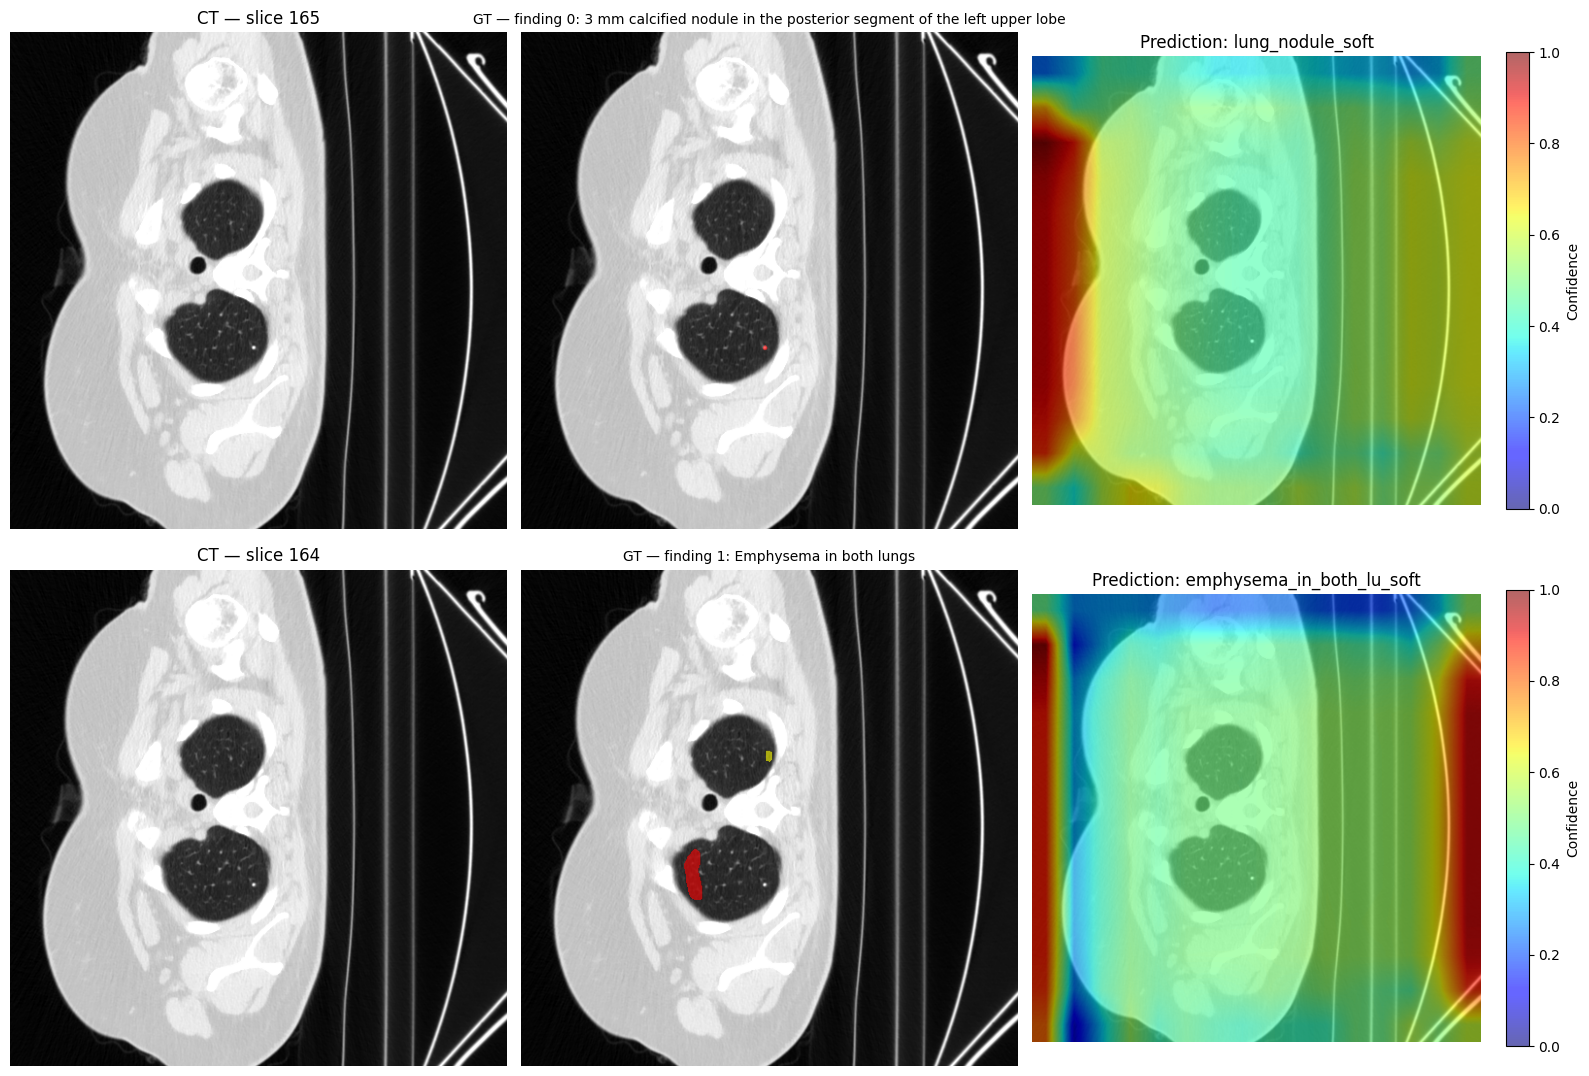

In [3]:
# ==================================================================
# train_13631_a_1: predicted mask vs RExGroundingCT ground truth vs CT
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import json

case = "train_13631_a_1"

pred_path = f"/home/chest_ct/code/models/merlin/results_full/{case}/localization_masks.npz"
findings_path = f"/home/chest_ct/code/models/merlin/results_full/{case}/findings.json"
ct_path = f"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/{case}.nii.gz"
gt_path = f"/home/chest_ct/code/data/segmentations/segmentations/{case}.nii.gz"

# --- load ---
pred_data = np.load(pred_path)
with open(findings_path) as f:
    findings_info = json.load(f)

ct_volume = np.asarray(nib.load(ct_path).dataobj)          # (H, W, D)
gt_volume = np.asarray(nib.load(gt_path).dataobj)          # (C, H, W, D), C = one channel per finding

print("Predicted mask keys:", pred_data.files)
print("CT shape:", ct_volume.shape)
print("GT shape:", gt_volume.shape)

# findings.json order matches both the predicted-mask key order and the GT channel order
finding_ids = list(findings_info["classified_findings"].keys())
pred_keys = pred_data.files

# transpose everything to (D, H, W)
ct_volume_d = np.transpose(ct_volume, (2, 0, 1))
gt_volume_d = np.transpose(gt_volume, (0, 3, 1, 2))  # (C, D, H, W)


def window_ct(ct_slice, wl=-600, ww=1500):
    lo, hi = wl - ww / 2, wl + ww / 2
    out = np.clip(ct_slice, lo, hi)
    return (out - lo) / (hi - lo + 1e-6)


n = len(finding_ids)
fig, axes = plt.subplots(n, 3, figsize=(16, 5.5 * n))
if n == 1:
    axes = axes.reshape(1, -1)

for row, fid in enumerate(finding_ids):
    text = findings_info["classified_findings"][fid]["text"]
    gt_mask_d = gt_volume_d[int(fid)]              # (D, H, W)
    pred_key = pred_keys[row]
    pred_mask = pred_data[pred_key]                 # (H, W, D)
    pred_mask_d = np.transpose(pred_mask, (2, 0, 1))  # (D, H, W)

    # pick slice with the most GT-positive pixels for this finding
    slice_idx = int(np.argmax(gt_mask_d.sum(axis=(1, 2))))

    ct_disp = window_ct(ct_volume_d[slice_idx])

    axes[row, 0].imshow(ct_disp, cmap="gray")
    axes[row, 0].set_title(f"CT — slice {slice_idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(ct_disp, cmap="gray")
    axes[row, 1].imshow(np.ma.masked_where(gt_mask_d[slice_idx] == 0, gt_mask_d[slice_idx]),
                         cmap="autumn", alpha=0.6)
    axes[row, 1].set_title(f"GT — finding {fid}: {text}", fontsize=10)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(ct_disp, cmap="gray")
    im = axes[row, 2].imshow(pred_mask_d[slice_idx], cmap="jet", alpha=0.6, vmin=0, vmax=1)
    axes[row, 2].set_title(f"Prediction: {pred_key}")
    axes[row, 2].axis("off")
    plt.colorbar(im, ax=axes[row, 2], label="Confidence", fraction=0.046)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np

embedding_path = "/home/chest_ct/code/models/merlin/results_full/train_12991_a_1/embedding.npz"
emb_data = np.load(embedding_path)

print("Keys in embedding.npz:", emb_data.files)
for key in emb_data.files:
    arr = emb_data[key]
    print(f"\n{key}: shape={arr.shape}, dtype={arr.dtype}")
    if arr.size <= 20:
        print(" values:", arr)
    else:
        print(f" min={arr.min():.4f}  max={arr.max():.4f}  mean={arr.mean():.4f}  std={arr.std():.4f}")
        print(f" L2 norm={np.linalg.norm(arr):.4f}")


Keys in embedding.npz: ['embedding']

embedding: shape=(1, 512), dtype=float32
 min=-0.6935  max=0.6496  mean=-0.0044  std=0.1948
 L2 norm=4.4095
